In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gan_data_gen import load_data_for_wgan, get_mean_std_error
from wgan import compare_dfs
import numpy as np

In [3]:
maxepochs_range = [2500, 5000, 7500]
dropout = 0.0
batchsize_range = [128, 256, 512]
lr = 1e-3

def get_train_data():
    df_train, _, categorical_mapping = load_data_for_wgan('data/train.parquet')
    pos_vars = ["hh_wgt", "consumption_per_capita_per_day", "popdensity", "yearly_rent"]
    for var in pos_vars:
        df_train[var] = np.exp(df_train["log_" + var])
        df_train.drop(columns=["log_" + var], inplace=True)
    for col in categorical_mapping:
        df_train[col] = df_train[col].astype('category').map(categorical_mapping[col])
    return df_train

def get_synthetic_data(maxepochs, lr, batchsize, dropout, trial):
    df_synthetic = pd.read_parquet(f'data/synthetic-maxepochs={maxepochs}_lr={lr}_batchsize={batchsize}_dropout={dropout}_trial={trial}_n=20000.parquet')
    return df_synthetic

def preprocess(df):
    numeric_columns = set(df.select_dtypes(include=[np.number]).columns)
    non_numeric_columns = set(
        df.select_dtypes(exclude=[np.number, np.datetime64]).columns
    )

    enforced_categorical = {c for c in numeric_columns if c.endswith("_nan")}
    numeric_columns = list(numeric_columns - enforced_categorical)
    all_non_numeric_columns = list(non_numeric_columns | enforced_categorical)

    one_hot = pd.get_dummies(df[all_non_numeric_columns])
    df.drop(columns=all_non_numeric_columns, inplace=True)
    df = pd.concat([df, one_hot], axis=1)
    return df

def add_missing_columns(df_synthetic, train_cols):
    missing_columns = [col for col in train_cols if col not in df_synthetic.columns]
    cols = [df_synthetic]
    for col in missing_columns:
        cols.append(pd.DataFrame({col: np.zeros(len(df_synthetic))}))
    df_synthetic = pd.concat(cols, axis=1)
    df_synthetic = df_synthetic[train_cols]
    return df_synthetic


df_train = preprocess(get_train_data())
df_synthetic = add_missing_columns(preprocess(get_synthetic_data(maxepochs_range[0], lr, batchsize_range[0], dropout, 0)), df_train.columns)



/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dryrun/lib/python3.8/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]


In [4]:
df_train.shape

(3430, 1051)

In [5]:
df_synthetic.shape

(20000, 1051)

In [6]:
hparams = []
for trial in range(5):
    for maxepochs in maxepochs_range:
        for batchsize in batchsize_range:
            df_synthetic = add_missing_columns(preprocess(get_synthetic_data(maxepochs, lr, batchsize, dropout, trial)), df_train.columns)
            mean_rmae, std_rmae = get_mean_std_error(df_train, df_synthetic)
            hparams.append({"maxepochs": maxepochs, "batchsize": batchsize, "mean_error": mean_rmae, "std_error": std_rmae, "total_error": mean_rmae + std_rmae, "trial":trial})

In [7]:
df = pd.DataFrame.from_records(hparams)
df.groupby(["maxepochs", "batchsize"]).agg(["mean", "std"])

mean_error           std_error           total_error  \
                          mean       std      mean       std        mean   
maxepochs batchsize                                                        
2500      128         0.004967  0.000677  0.026592  0.004112    0.031559   
          256         0.010045  0.005891  0.049809  0.020666    0.059854   
          512         0.017072  0.005583  0.069985  0.019316    0.087057   
5000      128         0.005959  0.000918  0.028051  0.004430    0.034011   
          256         0.005520  0.000963  0.026320  0.003889    0.031840   
          512         0.013761  0.007610  0.056709  0.025232    0.070470   
7500      128         0.006216  0.001747  0.027279  0.006443    0.033496   
          256         0.007595  0.002675  0.035476  0.013202    0.043071   
          512         0.014367  0.008078  0.056559  0.028920    0.070926   

                              trial            
                          std  mean       std  
maxepochs batchsize                            
2500      128        0.004775   2.0  1.581139  
          256        0.026495   2.0  1.581139  
          512        0.024702   2.0  1.581139  
5000      128        0.004733   2.0  1.581139  
          256        0.004154   2.0  1.581139  
          512        0.032780   2.0  1.581139  
7500      128        0.007984   2.0  1.581139  
          256        0.015729   2.0  1.581139  
          512        0.036986   2.0  1.581139

In [10]:
df1 = df_train
df2 = add_missing_columns(preprocess(get_synthetic_data(2500, 1e-3, 128, 0.0, 0)), df_train.columns)

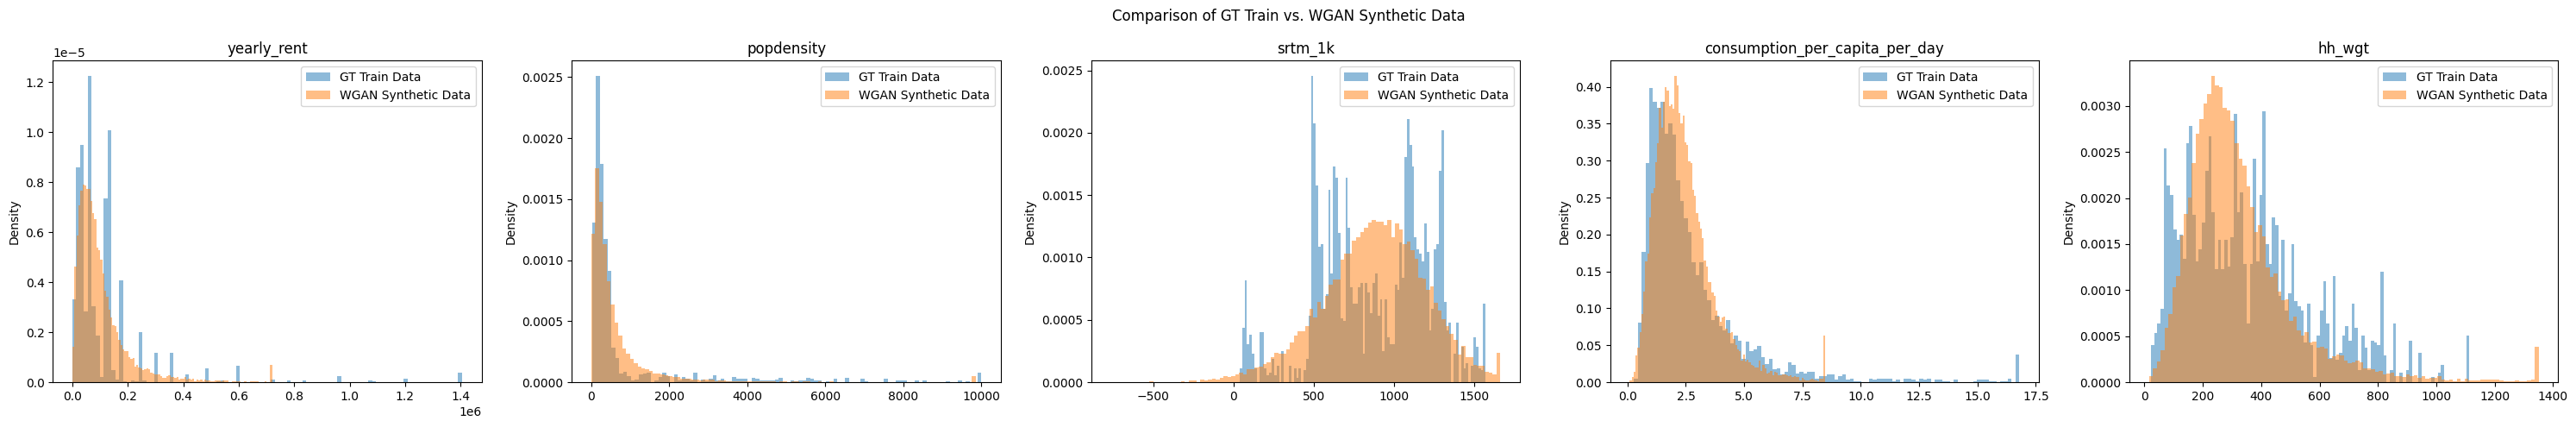

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))

features = ['yearly_rent', 'popdensity', 'srtm_1k', 'consumption_per_capita_per_day', 'hh_wgt']

plt.suptitle('Comparison of GT Train vs. WGAN Synthetic Data')

for i, feature in enumerate(features):
    axs[i].hist(np.clip(df1[feature], None, np.quantile(df1[feature], 0.995)), alpha=0.5, label='GT Train Data', density=True, bins=100)
    axs[i].hist(np.clip(df2[feature], None, np.quantile(df2[feature], 0.995)), alpha=0.5, label='WGAN Synthetic Data', density=True, bins=100)
    axs[i].set_title(feature)
    axs[i].set_ylabel('Density')
    axs[i].legend()
plt.tight_layout()
plt.savefig("figs/wgan.pdf")

